[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Tommy-Burns/easy-eo/blob/main/examples/01_fundamentals/06_statistics_and_extraction.ipynb)

# Statistics and value extraction

Finding where the extremes are, and reading values at specific places.

- **Data:** the bundled Copernicus DEM and Sentinel-2 sample
- **Network:** only for the first download of the sample

In [ ]:
# Running in Colab? Install Easy-EO. Does nothing anywhere else.
import sys

if "google.colab" in sys.modules:
    %pip install -q "easy-eo"


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

# Keeps the figures stored in this notebook small; raise it for print-quality output.
plt.rcParams["figure.dpi"] = 80

In [2]:
import numpy as np

from eeo import load_raster
from eeo.datasets import load_sample_dataset

sd = load_sample_dataset()

dem = load_raster(sd.copernicus_dem)
scene = load_raster(sd.sentinel2_stacked)

dem.describe(stats=True)

EEORasterDataset
  source      : /home/tommy/.cache/easy-eo/DEM.tif
  driver      : GTiff
  bands       : 1
  band names  : 1: elevation
  size        : 1024 × 1024  (height × width)
  dtype       : float32
  crs         : EPSG:32633 — WGS 84 / UTM zone 33N
  pixel size  : 10 × 10  (CRS units)
  extent      : 377720, 5340230, 387960, 5350470  (minx, miny, maxx, maxy)
  nodata      : -9999.0
  timestamp   : none
  attrs       : none

  statistics         : exact — full read
  band 1 (elevation) : min 356.379   max 559.63   mean 434.41   std 34.1611   valid 100.0% (0 nodata)


## Locating statistical pixels

These return both the value **and** where it is - which is usually the point. Each returns a dict with `value` and `position`.

In [3]:
highest = dem.get_maximum_pixel()
lowest = dem.get_minimum_pixel()

print("highest:", highest)
print("lowest :", lowest)
print(f"\nrelief : {highest['value'] - lowest['value']:.1f} m")

highest: {'value': 559.6299438476562, 'position': (380520.0, 5340310.0)}
lowest : {'value': 356.3794860839844, 'position': (377720.0, 5350280.0)}

relief : 203.3 m


Positions come back in **spatial coordinates** (the raster's CRS) by default, because that is what you need to put a marker on a map or hand to another tool.  
Ask for pixel coordinates instead when you want to index the array - note the order is `(row, col)`, matching NumPy indexing rather than `(x, y)`.

In [4]:
spatial = dem.get_maximum_pixel()
pixel = dem.get_maximum_pixel(return_position_as_pixel_coordinate=True)

print("spatial (easting, northing):", spatial["position"])
print("pixel   (row, col)         :", pixel["position"])

row, col = pixel["position"]
print("value read straight from the array:", dem.get_band(1)[row, col])
print("matches the reported maximum      :", dem.get_band(1)[row, col] == spatial["value"])

spatial (easting, northing): (380520.0, 5340310.0)
pixel   (row, col)         : (1016, 280)
value read straight from the array: 559.62994
matches the reported maximum      : True


`get_mean_pixel` does not return the mean - it returns the *pixel closest to* the mean, which is a real location you can go and look at.

In [5]:
mean_pixel = dem.get_mean_pixel()
actual_mean = float(np.nanmean(dem.get_band(1)))

print("actual mean       :", f"{actual_mean:.3f} m")
print("closest pixel     :", f"{mean_pixel['value']:.3f} m at {mean_pixel['position']}")

actual mean       : 434.410 m
closest pixel     : 434.410 m at (386770.0, 5348300.0)


In [6]:
for percentile in (5, 25, 50, 75, 95):
    result = dem.get_percentile_pixel(percentile=percentile)
    easting, northing = result["position"]
    print(f"p{percentile:<3d} {result['value']:8.2f} m   at ({easting:.0f}, {northing:.0f})")

p5     383.00 m   at (387880, 5349400)
p25    410.12 m   at (379400, 5347570)
p50    431.67 m   at (380680, 5347640)
p75    454.95 m   at (383470, 5341690)
p95    495.45 m   at (380810, 5346900)


### Choosing a band

On a multi-band raster, pass `band_idx` - by name or 1-based number. It defaults to the first band.

In [7]:
for band in scene.band_names:
    result = scene.get_maximum_pixel(band_idx=band)
    print(f"{band:6s} max {result['value']:6.0f} at {result['position']}")

blue   max  18496 at (385230.0, 5346800.0)
green  max  17584 at (385230.0, 5346800.0)
red    max  17024 at (387670.0, 5340580.0)
nir    max  16480 at (387670.0, 5340580.0)


## Extracting a value at a coordinate

`extract_value_at_coordinate` samples one point. The coordinate is in the **raster's own CRS** - here UTM zone 33N metres, not longitude and latitude.

In [8]:
bounds = dem.get_bounds()
centre = ((bounds.left + bounds.right) / 2, (bounds.bottom + bounds.top) / 2)

print("centre coordinate :", centre)
print("elevation         :", f"{dem.extract_value_at_coordinate(centre):.2f} m")

centre coordinate : (382840.0, 5345350.0)
elevation         : 457.10 m


If your coordinates are in lon/lat, convert them first. `pyproj` does this in two lines.

In [9]:
from pyproj import Transformer

lon, lat = 13.42, 48.25          # somewhere inside the scene
to_utm = Transformer.from_crs("EPSG:4326", dem.get_crs(), always_xy=True)
easting, northing = to_utm.transform(lon, lat)

print(f"lon/lat  {lon}, {lat}")
print(f"utm 33n  {easting:.1f}, {northing:.1f}")
print(f"elevation {dem.extract_value_at_coordinate((easting, northing)):.2f} m")

lon/lat  13.42, 48.25
utm 33n  382711.3, 5345294.0
elevation 434.48 m


Sampling a specific band works the same way - useful for reading a spectrum at a point.

In [10]:
point = (easting, northing)

print(f"{'band':6s} {'reflectance':>12s}")
for band in scene.band_names:
    dn = scene.extract_value_at_coordinate(point, band_idx=band)
    print(f"{band:6s} {dn / 10000:12.4f}")

band    reflectance
blue         0.1269
green        0.1508
red          0.1308
nir          0.5152


### Sampling many points

Loop for a handful; for a lot of points, read the array once and index it, which avoids re-reading the raster per point.

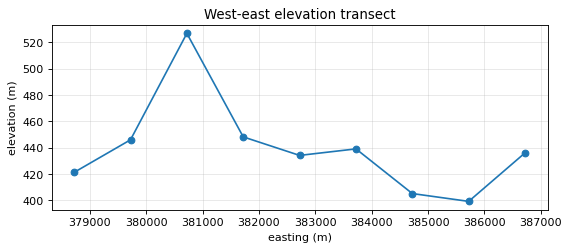

In [11]:
transect = [(bounds.left + 1000 * i, (bounds.bottom + bounds.top) / 2) for i in range(1, 10)]

elevations = [dem.extract_value_at_coordinate(p) for p in transect]

plt.figure(figsize=(8, 3))
plt.plot([p[0] for p in transect], elevations, marker="o")
plt.xlabel("easting (m)")
plt.ylabel("elevation (m)")
plt.title("West-east elevation transect")
plt.grid(alpha=0.3)
plt.show()

## Statistics over an area

For a region rather than a point, clip first and then use NumPy on the result - Easy-EO deliberately leaves the aggregation to NumPy rather than wrapping it.

In [12]:
import geopandas as gpd

roi = gpd.read_file(sd.boundary)
inside = dem.clip_raster_with_vector(roi)

values = inside.get_band(1).astype("float32")
nodata = inside.get_metadata()["nodata"]
valid = values[np.isfinite(values) & (values != nodata)]

print(f"pixels in ROI : {valid.size:,}")
print(f"mean          : {valid.mean():.2f} m")
print(f"std           : {valid.std():.2f} m")
print(f"min / max     : {valid.min():.2f} / {valid.max():.2f} m")

pixels in ROI : 279,112
mean          : 441.82 m
std           : 33.95 m
min / max     : 384.22 / 555.51 m


In [13]:
for ds in (dem, scene, inside):
    ds.close()
print("closed")

closed


## Next

- **[07_visualization](07_visualization.ipynb)** - the full plotting toolkit